# Reconstruct prices & measure cross-DEX gaps

Load the raw extracts, turn the irregular swap events into one aligned, gap-free price series per pool, then compare pools across DEXes.

Pipeline (each step is one `arblib.preprocessing` function):
1. **clean** — keep the last swap (end-of-block price) per pool & block
2. **split** — one series per pool address
3. **gap filter** — drop pools that trade too rarely to reconstruct
4. **reconstruct** — dense block grid, forward-filled prices, shared times
5. **study-start filter** — drop the warm-up margin
6. **analysis / plots** — cross-DEX pairwise price differences

In [27]:
%load_ext autoreload
%autoreload 2

from arblib import data_io, preprocessing as pp, analysis, plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

- **STUDY_START_TIME** — start of the study window. Must be *after* the collection start (`extract_arbitrage.ipynb`) so prices are already forward-filled for every pool when the study begins.
- **MAX_GAP_BLOCKS** — drop a pool if its largest gap between swaps exceeds this many blocks.

In [ ]:
from pathlib import Path

CHAIN = "base"


current = Path.cwd()
while current.name != 'defi_arbitrage' and current != current.parent:
    current = current.parent
BASE_DIR = current if current.name == 'defi_arbitrage' else Path.cwd()

DATA_DIR = BASE_DIR / f"{CHAIN}"

STUDY_START_TIME = "2025-01-01 00:00:00"
MAX_GAP_BLOCKS = 6000

## 0. Load the raw extracts

In [39]:
dfs = data_io.load_pool_csvs(DATA_DIR)

Loaded: df_uniswap.csv
          dex  evt_block_number               evt_block_time  evt_index  \
0  uniswap_v3          24433928  2024-12-31 15:00:03.000 UTC        698   
1  uniswap_v3          24433929  2024-12-31 15:00:05.000 UTC        326   
2  uniswap_v3          24433929  2024-12-31 15:00:05.000 UTC        118   
3  uniswap_v3          24433929  2024-12-31 15:00:05.000 UTC        385   
4  uniswap_v3          24433930  2024-12-31 15:00:07.000 UTC         63   

   evt_tx_index    mid_price                                        pool  \
0           136  3422.398763  0xb4cb800910b228ed3d0834cf79d697127bbb00e5   
1            78  3420.399274  0xb4cb800910b228ed3d0834cf79d697127bbb00e5   
2            24  3421.773212  0xb4cb800910b228ed3d0834cf79d697127bbb00e5   
3            97  3420.915427  0xb4cb800910b228ed3d0834cf79d697127bbb00e5   
4            14  3422.385585  0xb4cb800910b228ed3d0834cf79d697127bbb00e5   

                                       token0  token0_decimals  \
0  

## 1. Clean — keep the end-of-block price per pool & block

In [30]:
filtered_dfs = pp.clean_all(dfs)

Processed df_uniswap: 48519 rows -> 33988 rows
Processed df_pancake: 35118 rows -> 22784 rows
Processed df_aerodrome: 16166 rows -> 11319 rows


## 2. Split each DEX into one series per pool

In [31]:
pool_dfs = pp.split_by_pool(filtered_dfs)

Created uniswap_1: 39 rows
Created uniswap_2: 1145 rows
Created uniswap_3: 17 rows
Created uniswap_4: 694 rows
Created uniswap_5: 338 rows
Created uniswap_6: 18076 rows
Created uniswap_7: 13679 rows
Created pancake_1: 5 rows
Created pancake_2: 20324 rows
Created pancake_3: 2280 rows
Created pancake_4: 175 rows
Created aerodrome_1: 11190 rows
Created aerodrome_2: 129 rows

Total: 13 dataframes
['uniswap_1', 'uniswap_2', 'uniswap_3', 'uniswap_4', 'uniswap_5', 'uniswap_6', 'uniswap_7', 'pancake_1', 'pancake_2', 'pancake_3', 'pancake_4', 'aerodrome_1', 'aerodrome_2']


## 3. Drop pools that trade too rarely

In [32]:
pool_dfs, dropped_pools = pp.filter_pools_by_swap_gap(pool_dfs, MAX_GAP_BLOCKS)

k = 6000 blocks
Kept 10 pools

Kept pools:
  uniswap_2: 1145 swaps, max consecutive gap = 1819 blocks
  uniswap_4: 694 swaps, max consecutive gap = 701 blocks
  uniswap_5: 338 swaps, max consecutive gap = 1405 blocks
  uniswap_6: 18076 swaps, max consecutive gap = 31 blocks
  uniswap_7: 13679 swaps, max consecutive gap = 33 blocks
  pancake_2: 20324 swaps, max consecutive gap = 42 blocks
  pancake_3: 2280 swaps, max consecutive gap = 464 blocks
  pancake_4: 175 swaps, max consecutive gap = 3836 blocks
  aerodrome_1: 11190 swaps, max consecutive gap = 75 blocks
  aerodrome_2: 129 swaps, max consecutive gap = 2487 blocks

Dropped 3 pools:
  uniswap_1: max gap = 8503 blocks, tail gap = 4629 blocks
  uniswap_3: max gap = 7639 blocks, tail gap = 11706 blocks
  pancake_1: max gap = 187 blocks, tail gap = 32997 blocks


## 4. Reconstruct a dense, forward-filled series per pool

In [33]:
reconstructed_pools, global_min, global_max, block_time_map = (
    pp.reconstruct_pool_timeseries(pool_dfs)
)

Global block range: 24433927 to 24471726
Total blocks: 37800

uniswap_2: 1145 trades -> 37790 blocks (100.0%)
uniswap_4: 694 trades -> 37747 blocks (99.9%)
uniswap_5: 338 trades -> 37762 blocks (99.9%)
uniswap_6: 18076 trades -> 37799 blocks (100.0%)
uniswap_7: 13679 trades -> 37796 blocks (100.0%)
pancake_2: 20324 trades -> 37800 blocks (100.0%)
pancake_3: 2280 trades -> 37795 blocks (100.0%)
pancake_4: 175 trades -> 37579 blocks (99.4%)
aerodrome_1: 11190 trades -> 37800 blocks (100.0%)
aerodrome_2: 129 trades -> 37517 blocks (99.3%)

Created 10 reconstructed time series


## 5. Trim to the study window

In [34]:
filtered_pools = pp.filter_by_start_time(reconstructed_pools, STUDY_START_TIME)

uniswap_2: 37800 -> 17328 rows
uniswap_4: 37800 -> 17328 rows
uniswap_5: 37800 -> 17328 rows
uniswap_6: 37800 -> 17328 rows
uniswap_7: 37800 -> 17328 rows
pancake_2: 37800 -> 17328 rows
pancake_3: 37800 -> 17328 rows
pancake_4: 37800 -> 17328 rows
aerodrome_1: 37800 -> 17328 rows
aerodrome_2: 37800 -> 17328 rows

Filtered all pools by time >= 2025-01-01 00:00:00


## Plot — all Uniswap pools

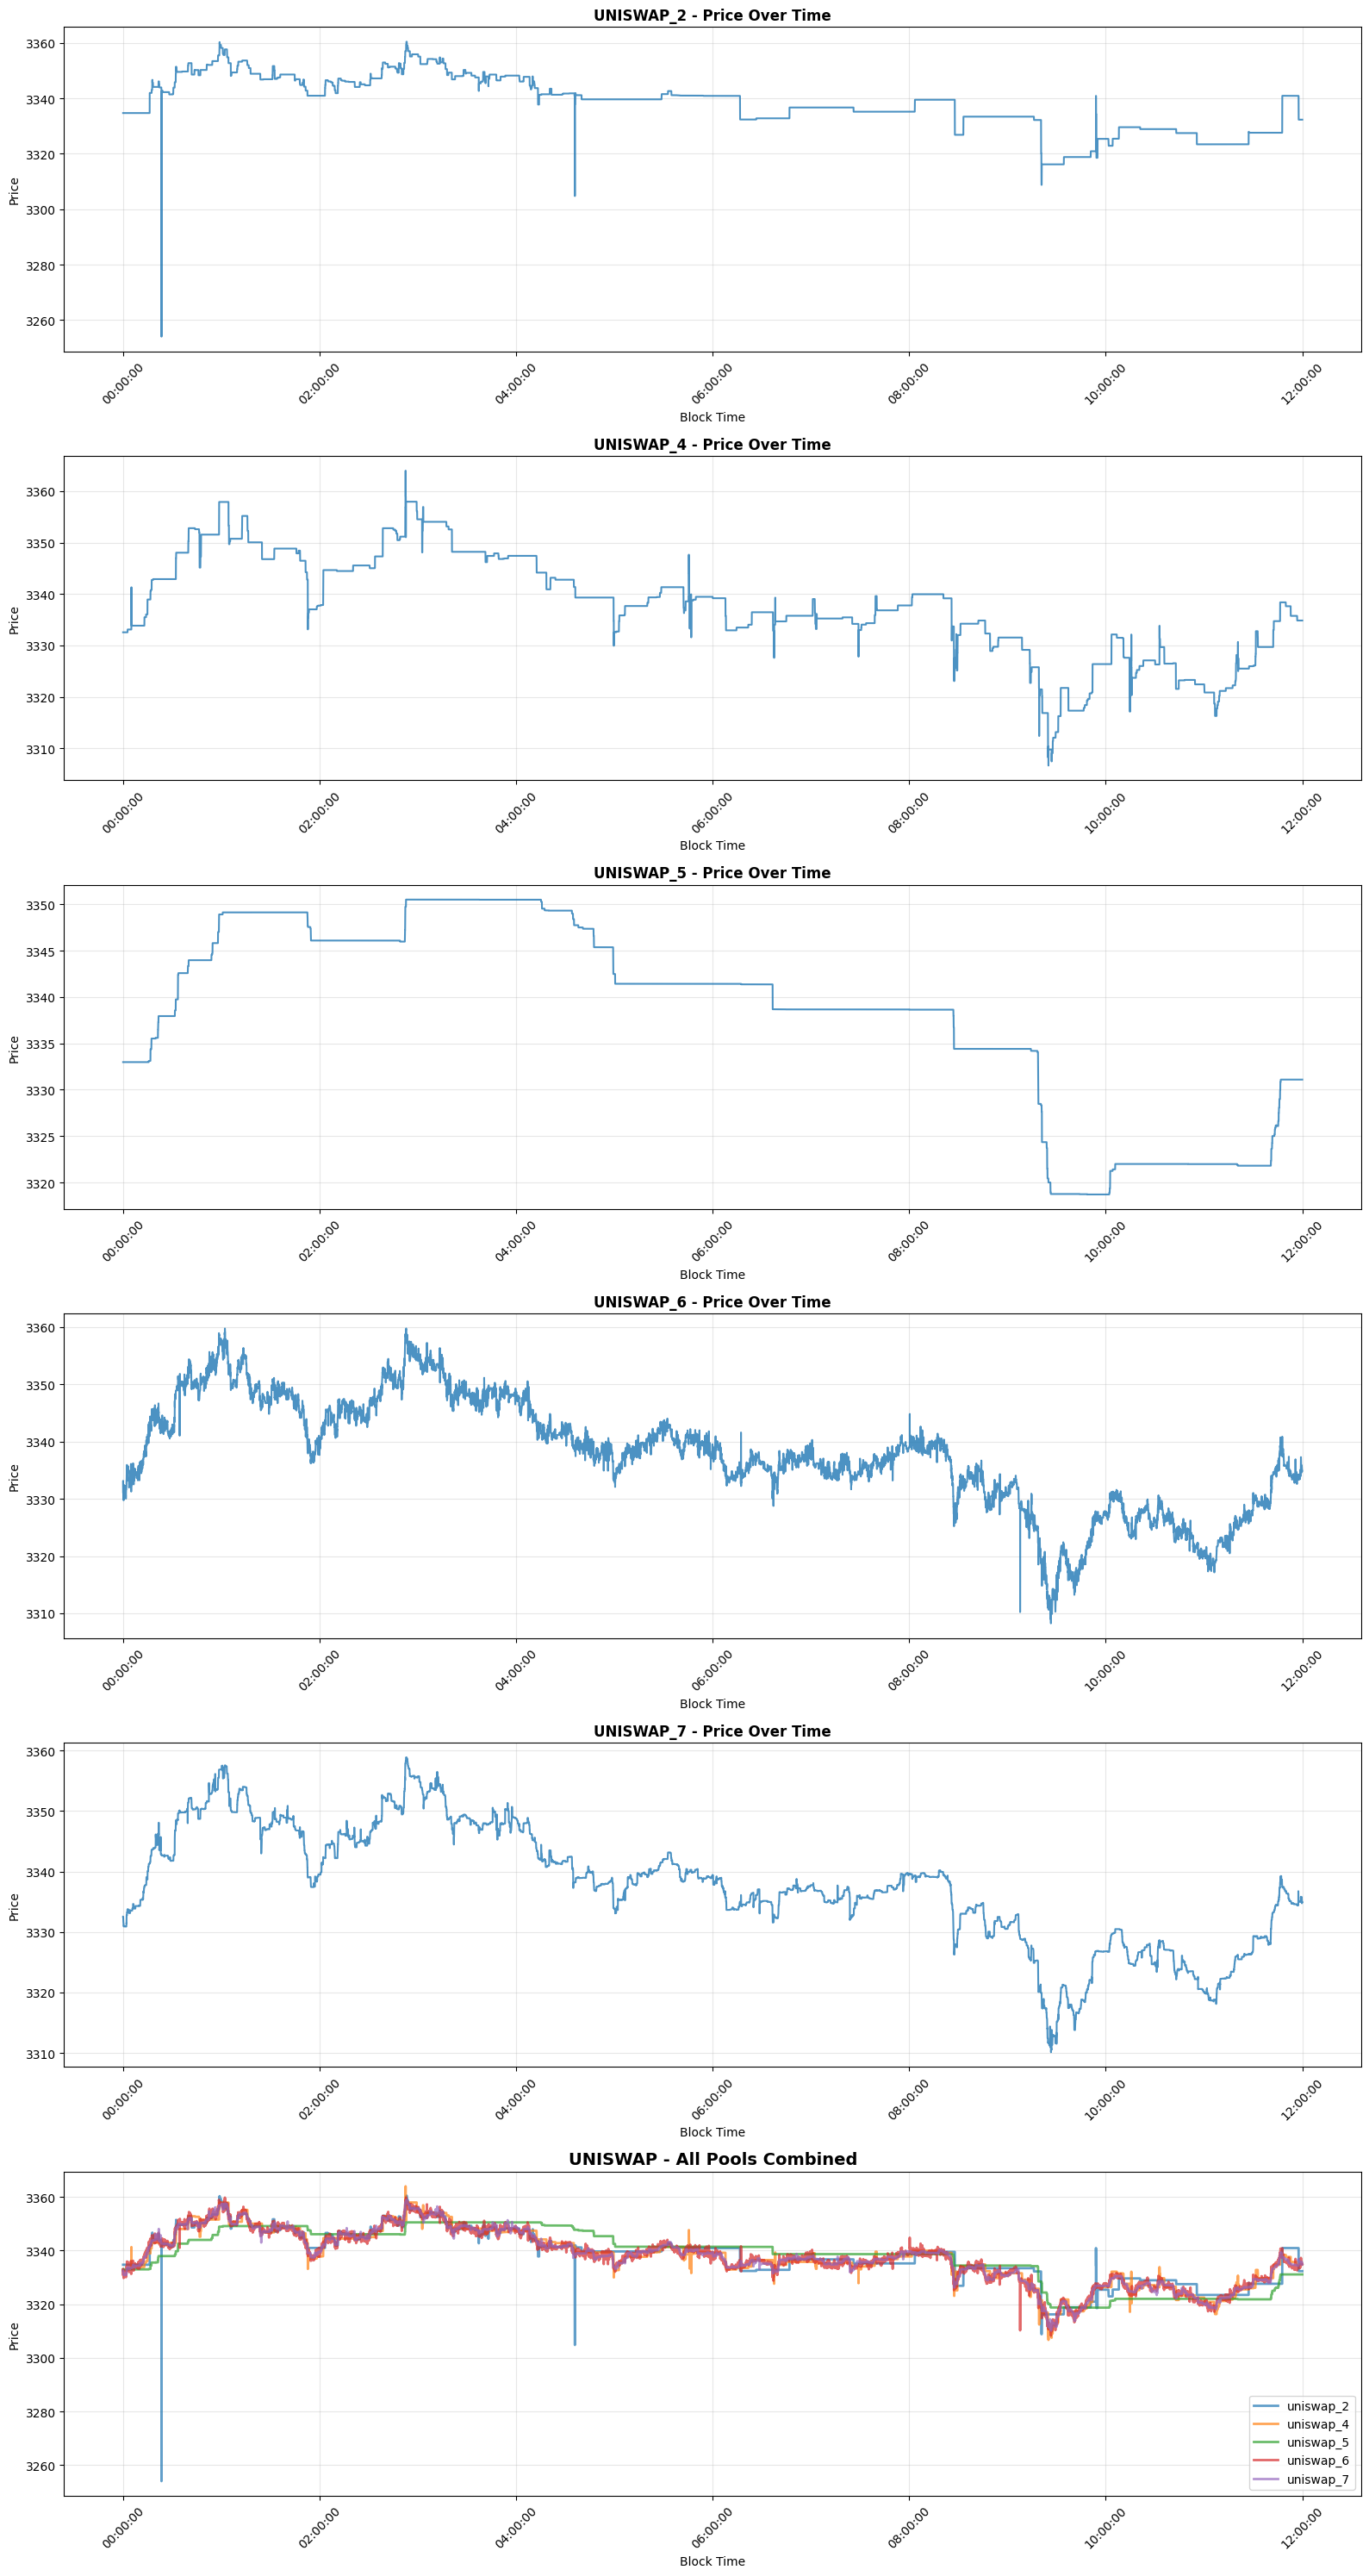


Plotted 5 uniswap pools + 1 combined view
  uniswap_2: 17328 blocks
  uniswap_4: 17328 blocks
  uniswap_5: 17328 blocks
  uniswap_6: 17328 blocks
  uniswap_7: 17328 blocks


In [35]:
plotting.plot_dex_pools(filtered_pools, dex="uniswap")

## 6. Cross-DEX pairwise price differences

In [36]:
price_differences, all_price_differences = analysis.compute_pairwise_differences(filtered_pools)

DEXes found: ['uniswap', 'pancake', 'aerodrome']
Pools per DEX: [('uniswap', 5), ('pancake', 3), ('aerodrome', 2)]

Computed 31 pairwise comparisons:

pancake_2_vs_aerodrome_1:
  Rows: 17328
  Max diff: 6.746171
  Mean diff: 0.633274
  Min diff: 0.000060

pancake_2_vs_aerodrome_2:
  Rows: 17328
  Max diff: 10.032618
  Mean diff: 2.259288
  Min diff: 0.000046

pancake_3_vs_aerodrome_1:
  Rows: 17328
  Max diff: 5.764152
  Mean diff: 0.485740
  Min diff: 0.000092

pancake_3_vs_aerodrome_2:
  Rows: 17328
  Max diff: 9.104597
  Mean diff: 1.976182
  Min diff: 0.004115

pancake_4_vs_aerodrome_1:
  Rows: 17328
  Max diff: 11.142325
  Mean diff: 3.356780
  Min diff: 0.000900

pancake_4_vs_aerodrome_2:
  Rows: 17328
  Max diff: 10.707028
  Mean diff: 2.907941
  Min diff: 0.045351

uniswap_2_vs_aerodrome_1:
  Rows: 17328
  Max diff: 88.304454
  Mean diff: 1.876928
  Min diff: 0.000061

uniswap_2_vs_aerodrome_2:
  Rows: 17328
  Max diff: 85.422180
  Mean diff: 2.517549
  Min diff: 0.008593

unis

## Plot — price series for every cross-DEX pair

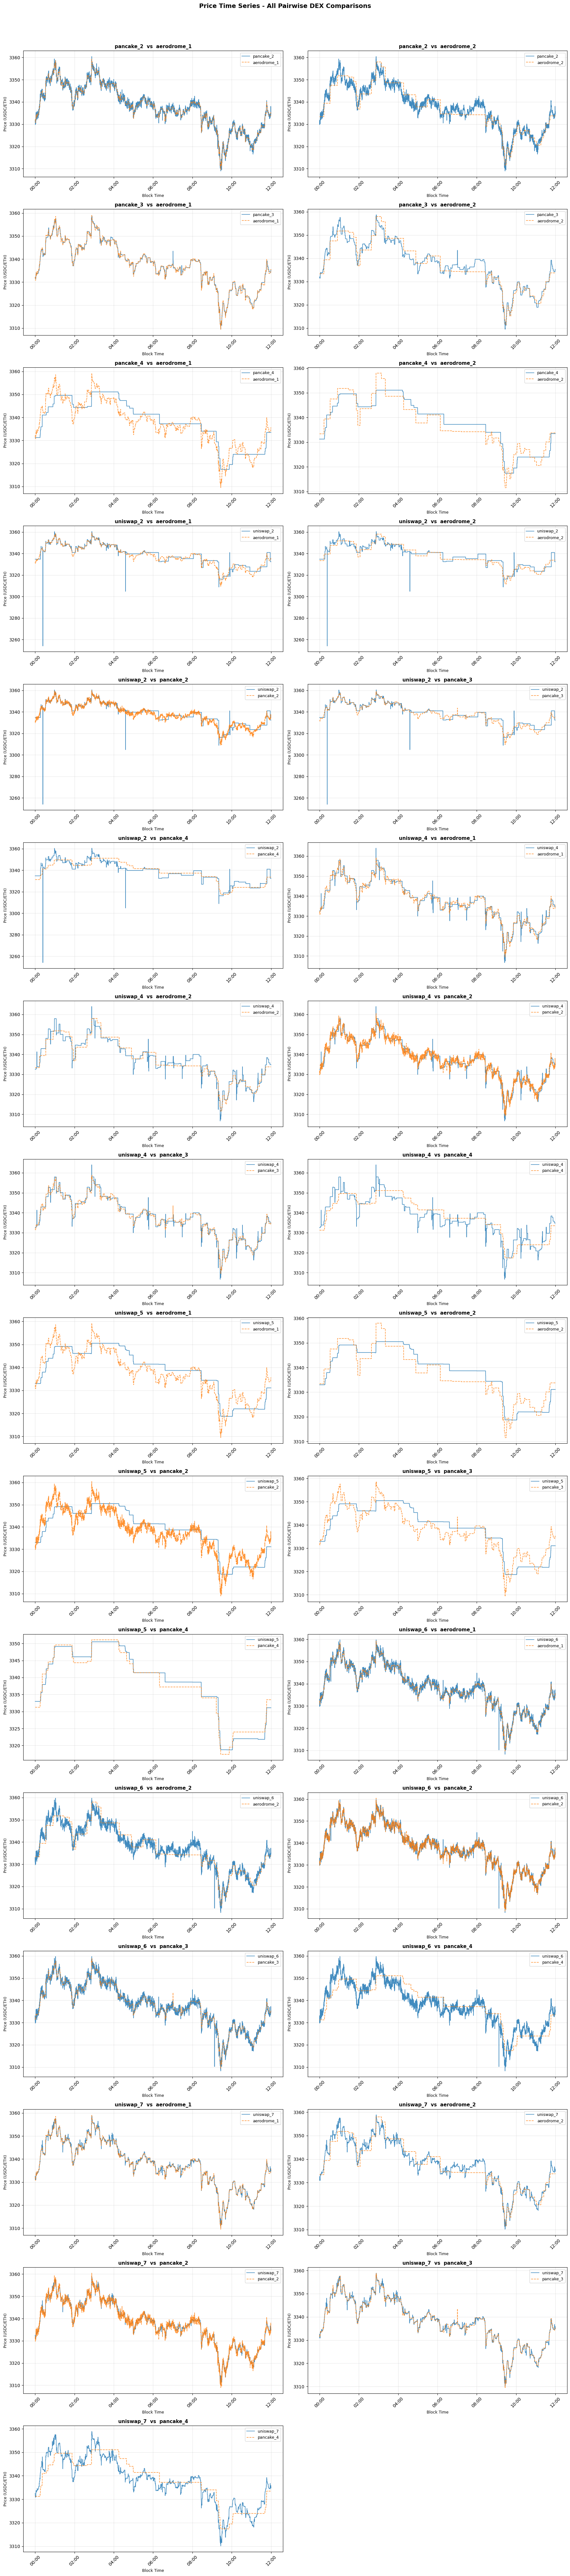

In [37]:
plotting.plot_pairwise_prices(price_differences)

In [ ]:
# quantite de token fin du block